# NN_07 — Compositor de Figuras: Comparação Unificada

**Objetivo**: Carregar os resultados pré-computados do NN_02b e NN_02c e produzir as figuras finais do artigo — sem re-treinar ou re-inferir modelos.

**Dependências** (devem estar executados antes):
- `NN_02b_Ablation_tau_variants.ipynb` → `nn02b_ablation_results.json`
- `NN_02c_Ablation_z_eq_variants.ipynb` → `nn02c_ablation_results.json`

**Figuras produzidas**:
| Figura | Conteúdo |
|--------|----------|
| `Fig_comparacao_principal.png` | Clássico vs CNN-1D vs núcleo mínimo [τ,E] vs 4-feat |
| `Fig_ablacao_tau_variants.png` | V5→V8→V1 (NN_02b) — descoberta do núcleo mínimo |
| `Fig_ablacao_zeq_variants.png` | A→D (NN_02c) — por que z_eq falha em baixo SNR |
| `Fig_comparacao_dois_estudos.png` | Painel lateral: NN_02b e NN_02c lado a lado |

**Nota**: Este notebook só lê JSON e plota. Não requer GPU. Pode ser re-executado a qualquer momento após NN_02b e NN_02c terem sido executados.

In [2]:
# ==============================================================================
# 1. IMPORTS & CARREGAR RESULTADOS DOS ABLATION STUDIES
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

project_root = Path.cwd().parent
results_dir  = project_root / "results"
data_dir     = results_dir / "data"
vis_dir      = results_dir / "visualizations"
vis_dir.mkdir(parents=True, exist_ok=True)

# ── Carregar resultados NN_02b (τ-variants) ───────────────────────────────────
path_02b = data_dir / "nn02b_ablation_results.json"
if not path_02b.exists():
    raise FileNotFoundError(
        f"Execute NN_02b_Ablation_tau_variants.ipynb primeiro.\nEsperado: {path_02b}"
    )
with open(path_02b) as f:
    res_02b = json.load(f)

# ── Carregar resultados NN_02c (z_eq-variants) ────────────────────────────────
path_02c = Path("/mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/models/nn02c_ablation_results.json")
if not path_02c.exists():
    raise FileNotFoundError(
        f"Execute NN_02c_Ablation_z_eq_variants.ipynb primeiro.\nEsperado: {path_02c}"
    )
with open(path_02c) as f:
    res_02c = json.load(f)

SNR_BINS = res_02b['metadata']['snr_bins']
ALPHA    = res_02b['metadata']['alpha']
snr_arr  = np.array(SNR_BINS)

# Correlador clássico (referência analítica — Xie 2021)
CLASSICAL_PD = {int(k): v for k, v in res_02b['classical_correlator'].items()}

print(f"NN_02b carregado: {len(res_02b['variants'])} variantes")
print(f"  Variantes τ: {list(res_02b['variants'].keys())}")
print(f"\nNN_02c carregado: {len(res_02c['variants'])} variantes")
print(f"  Variantes z_eq: {list(res_02c['variants'].keys())}")
print(f"\nSNR bins: {SNR_BINS}")
print(f"α = {ALPHA:.0e}  (D3F threshold)")

NN_02b carregado: 5 variantes
  Variantes τ: ['V5_tau_only', 'V6_tau_h', 'V7_h_snr', 'V8_h_energy', 'V1_baseline']

NN_02c carregado: 5 variantes
  Variantes z_eq: ['A', 'B', 'C', 'D', 'E']

SNR bins: [0, 5, 10, 15, 20, 25, 30]
α = 1e-07  (D3F threshold)


## Figura 1 — Comparação Principal

Mostra o resultado central do artigo: a hierarquia das representações de entrada.

- **Clássico**: correlador analítico (Xie 2021) — referência
- **z_eq (1D CNN)**: NN_02c Variant A — falha abaixo de 15 dB  
- **z_eq - tag_ref**: NN_02c Variant E — residual explícito com TAG legítima
- **[|τ|] isolado**: V5 do NN_02b — sem info de canal, falha em 0 dB
- **[|τ|, E]**: V8 do NN_02b — núcleo mínimo, 87.2% a 0 dB
- **[|τ|, ĥ, SNR̄, E]**: V1 do NN_02b — 4 características, menos eficiente que V8

In [3]:
# ==============================================================================
# 2. EXTRAIR CURVAS PD vs SNR
# ==============================================================================

def get_pd(results_dict, variant_key):
    """Extrai array de PD para os SNR_BINS a partir do dict de resultados."""
    v = results_dict['variants'].get(variant_key, {})
    pd_dict = v.get('pd_vs_snr') or v.get('pd_d3f', {})
    return np.array([pd_dict.get(str(s), pd_dict.get(s, 0.0)) for s in SNR_BINS])

# ── NN_02b (τ-variants) ───────────────────────────────────────────────────────
pd_v5_tau_only   = get_pd(res_02b, 'V5_tau_only')    # |τ| isolado
pd_v7_tau_snr    = get_pd(res_02b, 'V7_tau_snr')     # [|τ|, SNR̄]
pd_v6_tau_h      = get_pd(res_02b, 'V6_tau_h')       # [|τ|, ĥ]
pd_v8_tau_energy = get_pd(res_02b, 'V8_tau_energy')  # [|τ|, E] — núcleo mínimo
pd_v1_baseline   = get_pd(res_02b, 'V1_baseline')    # [|τ|, ĥ, SNR̄, E] — 4-feat
pd_v2_perfect_h  = get_pd(res_02b, 'V2_perfect_h')   # h perfeito
pd_v3_no_snr     = get_pd(res_02b, 'V3_no_snr')      # sem SNR
pd_v4_no_energy  = get_pd(res_02b, 'V4_no_energy')   # sem E

# ── NN_02c (z_eq-variants) ────────────────────────────────────────────────────
pd_c_A = get_pd(res_02c, 'A')  # z_eq (1D CNN pura)
pd_c_B = get_pd(res_02c, 'B')  # z_eq + h
pd_c_C = get_pd(res_02c, 'C')  # z_eq + h + SNR
pd_c_D = get_pd(res_02c, 'D')  # z_eq + |τ|
pd_c_E = get_pd(res_02c, 'E')  # z_eq - tag_ref

# ── Clássico ──────────────────────────────────────────────────────────────────
pd_classical = np.array([CLASSICAL_PD.get(s, 0.0) for s in SNR_BINS])

# Impressão sumária
print(f"{'Método':<30}  {'0dB':>7}  {'5dB':>7}  {'10dB':>7}  {'15dB':>7}")
print("-" * 60)
for label, arr in [
    ("Clássico",          pd_classical),
    ("z_eq CNN-1D (Var A)", pd_c_A),
    ("V5 [|τ|] isolado",  pd_v5_tau_only),
    ("V7 [|τ|, SNR̄]",   pd_v7_tau_snr),
    ("V6 [|τ|, ĥ]",      pd_v6_tau_h),
    ("V8 [|τ|, E] ★",    pd_v8_tau_energy),
    ("V1 [4-feat]",       pd_v1_baseline),
    ("z_eq+τ (Var D)",    pd_c_D),
    ("z_eq-tag_ref (Var E)", pd_c_E),
]:
    vals = "  ".join(f"{v*100:>7.1f}" for v in arr[:4])
    print(f"{label:<30}  {vals}")

Método                              0dB      5dB     10dB     15dB
------------------------------------------------------------
Clássico                            8.1     58.7     99.9    100.0
z_eq CNN-1D (Var A)                 0.1      0.2      0.0     88.3
V5 [|τ|] isolado                    0.0     99.0    100.0    100.0
V7 [|τ|, SNR̄]                      0.0      0.0      0.0      0.0
V6 [|τ|, ĥ]                        84.7     99.6    100.0    100.0
V8 [|τ|, E] ★                       0.0      0.0      0.0      0.0
V1 [4-feat]                        83.7     99.4    100.0    100.0
z_eq+τ (Var D)                     88.2     99.8    100.0    100.0
z_eq-tag_ref (Var E)                0.2      0.2      0.0      0.0


## Figura 1 — Comparação Principal (para o artigo)

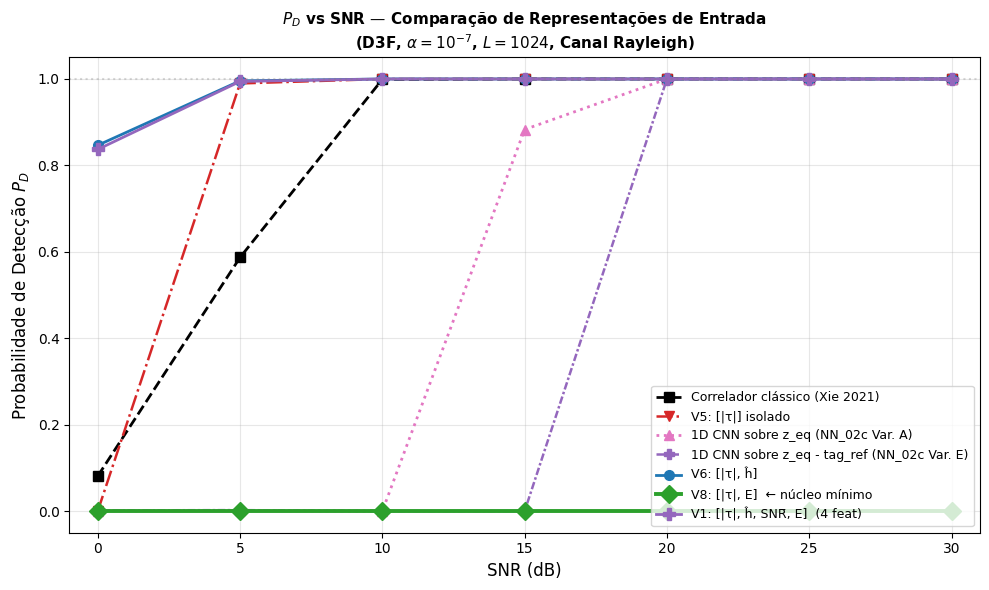

Salvo → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/visualizations/Fig_comparacao_principal.png


In [4]:
# ==============================================================================
# 3. FIGURA 1 — COMPARAÇÃO PRINCIPAL (artigo Fig. fig_pd_snr)
# ==============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

# --- Métodos que falham (vermelho/laranja) ------------------------------------
ax.plot(snr_arr, pd_classical, color='black', ls='--', lw=2, marker='s', ms=7,
        label='Correlador clássico (Xie 2021)')

ax.plot(snr_arr, pd_v5_tau_only, color='#d62728', ls='-.', lw=1.8, marker='v', ms=7,
        label='V5: [|τ|] isolado')

ax.plot(snr_arr, pd_c_A, color='#e377c2', ls=':', lw=2, marker='^', ms=7,
        label='1D CNN sobre z_eq (NN_02c Var. A)')

ax.plot(snr_arr, pd_c_E, color='#9467bd', ls=(0, (3, 1, 1, 1)), lw=1.8, marker='P', ms=7,
        label='1D CNN sobre z_eq - tag_ref (NN_02c Var. E)')

# --- Métodos eficazes (azul/verde) --------------------------------------------
ax.plot(snr_arr, pd_v6_tau_h, color='#1f77b4', ls='-', lw=2, marker='o', ms=7,
        label='V6: [|τ|, ĥ]')

ax.plot(snr_arr, pd_v8_tau_energy, color='#2ca02c', ls='-', lw=2.8, marker='D', ms=9,
        label='V8: [|τ|, E]  ← núcleo mínimo')

ax.plot(snr_arr, pd_v1_baseline, color='#9467bd', ls='-', lw=2, marker='P', ms=8,
        label='V1: [|τ|, ĥ, SNR̄, E]  (4 feat)')

ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('Probabilidade de Detecção $P_D$', fontsize=12)
ax.set_title(
    f'$P_D$ vs SNR — Comparação de Representações de Entrada\n'
    f'(D3F, $\\alpha = 10^{{-7}}$, $L = 1024$, Canal Rayleigh)',
    fontsize=11, fontweight='bold'
)
ax.set_xlim(-1, 31); ax.set_ylim(-0.05, 1.05)
ax.set_xticks(SNR_BINS)
ax.axhline(1.0, color='gray', ls=':', alpha=0.3)
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
fig_path1 = vis_dir / "Fig_comparacao_principal.png"
plt.savefig(str(fig_path1), dpi=150)
plt.show()
print(f"Salvo → {fig_path1}")

## Figura 2 — Dois Estudos Lado a Lado

Painel esquerdo: NN_02b (τ-variants) — progressão V5→V8, descoberta do núcleo mínimo.  
Painel direito: NN_02c (z_eq-variants) — falha estrutural abaixo de 15 dB e o papel do τ.

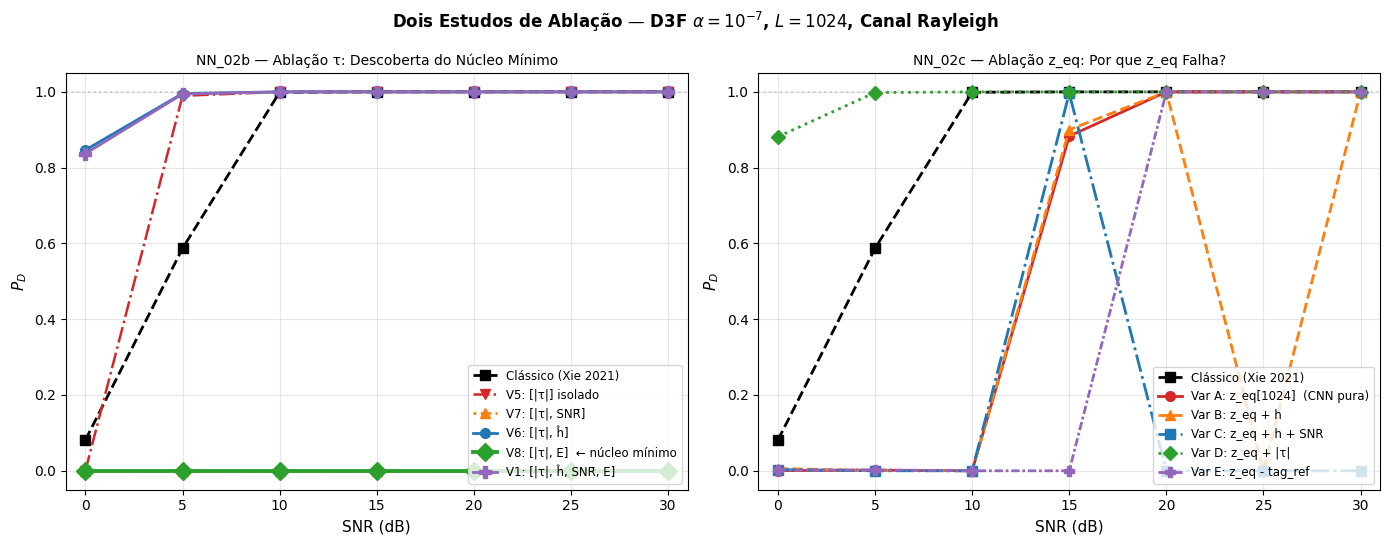

Salvo → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/visualizations/Fig_comparacao_dois_estudos.png


In [5]:
# ==============================================================================
# 4. FIGURA 2 — DOIS ESTUDOS LADO A LADO (artigo Fig. fig_ablation_pd_snr)
# ==============================================================================

COLORS_02C = {'A': '#d62728', 'B': '#ff7f0e', 'C': '#1f77b4', 'D': '#2ca02c', 'E': '#9467bd'}
LS_02C     = {'A': '-', 'B': '--', 'C': '-.', 'D': ':', 'E': (0, (3, 1, 1, 1))}
MK_02C     = {'A': 'o', 'B': '^', 'C': 's', 'D': 'D', 'E': 'P'}
PD_02C     = {'A': pd_c_A, 'B': pd_c_B, 'C': pd_c_C, 'D': pd_c_D, 'E': pd_c_E}
LABEL_02C  = {
    'A': 'Var A: z_eq[1024]  (CNN pura)',
    'B': 'Var B: z_eq + h',
    'C': 'Var C: z_eq + h + SNR',
    'D': 'Var D: z_eq + |τ|',
    'E': 'Var E: z_eq - tag_ref',
}

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(
    f'Dois Estudos de Ablação — D3F $\\alpha=10^{{-7}}$, $L=1024$, Canal Rayleigh',
    fontsize=12, fontweight='bold'
)

# ── Painel esquerdo: NN_02b (τ-variants) ─────────────────────────────────────
ax = ax_left
ax.set_title('NN_02b — Ablação τ: Descoberta do Núcleo Mínimo', fontsize=10)

ax.plot(snr_arr, pd_classical,   color='black',   ls='--', lw=2,  marker='s', ms=7,
        label='Clássico (Xie 2021)')
ax.plot(snr_arr, pd_v5_tau_only,  color='#d62728', ls='-.', lw=1.8, marker='v', ms=7,
        label='V5: [|τ|] isolado')
ax.plot(snr_arr, pd_v7_tau_snr,   color='#ff7f0e', ls=':',  lw=2,  marker='^', ms=7,
        label='V7: [|τ|, SNR̄]')
ax.plot(snr_arr, pd_v6_tau_h,     color='#1f77b4', ls='-',  lw=2,  marker='o', ms=7,
        label='V6: [|τ|, ĥ]')
ax.plot(snr_arr, pd_v8_tau_energy, color='#2ca02c', ls='-', lw=2.8, marker='D', ms=9,
        label='V8: [|τ|, E]  ← núcleo mínimo')
ax.plot(snr_arr, pd_v1_baseline,  color='#9467bd', ls='-',  lw=2,  marker='P', ms=8,
        label='V1: [|τ|, ĥ, SNR̄, E]')

ax.set_xlabel('SNR (dB)', fontsize=11); ax.set_ylabel('$P_D$', fontsize=11)
ax.set_xlim(-1, 31); ax.set_ylim(-0.05, 1.05); ax.set_xticks(SNR_BINS)
ax.axhline(1.0, color='gray', ls=':', alpha=0.3)
ax.legend(fontsize=8.5, loc='lower right'); ax.grid(alpha=0.3)

# ── Painel direito: NN_02c (z_eq-variants) ───────────────────────────────────
ax = ax_right
ax.set_title('NN_02c — Ablação z_eq: Por que z_eq Falha?', fontsize=10)

ax.plot(snr_arr, pd_classical, color='black', ls='--', lw=2, marker='s', ms=7,
        label='Clássico (Xie 2021)')
for var in ['A', 'B', 'C', 'D', 'E']:
    ax.plot(snr_arr, PD_02C[var],
            color=COLORS_02C[var], ls=LS_02C[var], lw=2, marker=MK_02C[var], ms=7,
            label=LABEL_02C[var])

ax.set_xlabel('SNR (dB)', fontsize=11); ax.set_ylabel('$P_D$', fontsize=11)
ax.set_xlim(-1, 31); ax.set_ylim(-0.05, 1.05); ax.set_xticks(SNR_BINS)
ax.axhline(1.0, color='gray', ls=':', alpha=0.3)
ax.legend(fontsize=8.5, loc='lower right'); ax.grid(alpha=0.3)

plt.tight_layout()
fig_path2 = vis_dir / "Fig_comparacao_dois_estudos.png"
plt.savefig(str(fig_path2), dpi=150)
plt.show()
print(f"Salvo → {fig_path2}")

## Figure 2 (GPU) — PD vs SNR, α-constrained

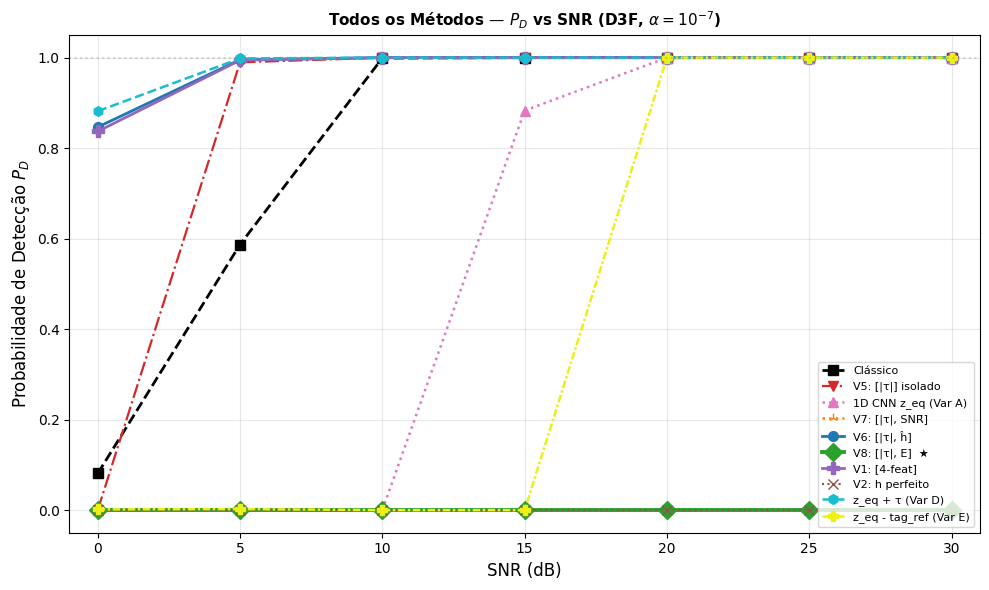

Salvo → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/visualizations/Fig_todos_metodos.png


In [6]:
# ==============================================================================
# 5. FIGURA 3 — TABELA COMPLETA (todos os métodos)
# ==============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

PLOT_CONFIG = [
    # (label,               array,            color,      ls,    lw,   mk,  ms)
    ('Clássico',            pd_classical,     'black',   '--',  2.0,  's', 7),
    ('V5: [|τ|] isolado',  pd_v5_tau_only,   '#d62728', '-.',  1.6,  'v', 7),
    ('1D CNN z_eq (Var A)',pd_c_A,            '#e377c2', ':',   1.8,  '^', 7),
    ('V7: [|τ|, SNR̄]',   pd_v7_tau_snr,    '#ff7f0e', ':',   1.8,  '2', 7),
    ('V6: [|τ|, ĥ]',      pd_v6_tau_h,      '#1f77b4', '-',   2.0,  'o', 7),
    ('V8: [|τ|, E]  ★',   pd_v8_tau_energy, '#2ca02c', '-',   2.8,  'D', 9),
    ('V1: [4-feat]',       pd_v1_baseline,   '#9467bd', '-',   2.0,  'P', 8),
    ('V2: h perfeito',     pd_v2_perfect_h,  '#8c564b', ':',   1.5,  'x', 7),
    ('z_eq + τ (Var D)',   pd_c_D,           '#17becf', '--',  1.8,  'h', 7),
    ('z_eq - tag_ref (Var E)', pd_c_E,       "#ecf017", (0, (3, 1, 1, 1)), 1.8, 'P', 7),
]

for label, arr, color, ls, lw, mk, ms in PLOT_CONFIG:
    ax.plot(snr_arr, arr, color=color, ls=ls, lw=lw, marker=mk, ms=ms, label=label)

ax.set_xlabel('SNR (dB)', fontsize=12)
ax.set_ylabel('Probabilidade de Detecção $P_D$', fontsize=12)
ax.set_title(
    f'Todos os Métodos — $P_D$ vs SNR (D3F, $\\alpha=10^{{-7}}$)',
    fontsize=11, fontweight='bold'
)
ax.set_xlim(-1, 31); ax.set_ylim(-0.05, 1.05)
ax.set_xticks(SNR_BINS)
ax.axhline(1.0, color='gray', ls=':', alpha=0.3)
ax.legend(fontsize=8, loc='lower right', ncol=1)
ax.grid(alpha=0.3)
plt.tight_layout()
fig_path3 = vis_dir / "Fig_todos_metodos.png"
plt.savefig(str(fig_path3), dpi=150)
plt.show()
print(f"Salvo → {fig_path3}")

In [16]:
# ==============================================================================
# 6. TABELA NUMÉRICA CONSOLIDADA E SAVE JSON
# ==============================================================================

METHODS = [
    ('Clássico',           pd_classical),
    ('V5 [|τ|]',          pd_v5_tau_only),
    ('z_eq CNN (Var A)',   pd_c_A),
    ('V7 [|τ|, SNR̄]',   pd_v7_tau_snr),
    ('V6 [|τ|, ĥ]',      pd_v6_tau_h),
    ('V8 [|τ|, E] ★',    pd_v8_tau_energy),
    ('V1 [4-feat]',        pd_v1_baseline),
    ('V2 h perfeito',      pd_v2_perfect_h),
    ('V3 sem SNR',         pd_v3_no_snr),
    ('V4 sem E',           pd_v4_no_energy),
    ('z_eq+h (Var B)',     pd_c_B),
    ('z_eq+h+SNR (Var C)', pd_c_C),
    ('z_eq+τ (Var D)',     pd_c_D),
    ('z_eq-tag_ref (Var E)', pd_c_E),
]

header = "  ".join(f"{s:>5}dB" for s in SNR_BINS)
print(f"\n{'Método':<24}  {header}")
print("-" * 90)
for label, arr in METHODS:
    vals = "  ".join(f"{v*100:>7.1f}" for v in arr)
    marker = " ★" if "★" in label else ""
    print(f"{label:<24}  {vals}{marker}")

# Salvar JSON consolidado
out_path = data_dir / "nn07_unified_comparison.json"
save = {
    'metadata': {
        'alpha': ALPHA,
        'snr_bins': SNR_BINS,
        'sources': ['nn02b_ablation_results.json', 'nn02c_ablation_results.json'],
    },
    'methods': {
        label: {str(s): float(v) for s, v in zip(SNR_BINS, arr)}
        for label, arr in METHODS
    }
}
with open(out_path, 'w') as f:
    json.dump(save, f, indent=2)
print(f"\nResultados consolidados salvos → {out_path}")
print(f"\nFiguras salvas em: {vis_dir}")


Método                        0dB      5dB     10dB     15dB     20dB     25dB     30dB
------------------------------------------------------------------------------------------
Clássico                      8.1     58.7     99.9    100.0    100.0    100.0    100.0
V5 [|τ|]                      0.0     99.0    100.0    100.0    100.0    100.0    100.0
z_eq CNN (Var A)              0.1      0.2      0.0     88.3    100.0    100.0    100.0
V7 [|τ|, SNR̄]                0.0      0.0      0.0      0.0      0.0      0.0      0.0
V6 [|τ|, ĥ]                  84.7     99.6    100.0    100.0    100.0    100.0    100.0
V8 [|τ|, E] ★                 0.0      0.0      0.0      0.0      0.0      0.0      0.0 ★
V1 [4-feat]                  83.7     99.4    100.0    100.0    100.0    100.0    100.0
V2 h perfeito                 0.0      0.0      0.0      0.0      0.0      0.0      0.0
V3 sem SNR                    0.0      0.0      0.0      0.0      0.0      0.0      0.0
V4 sem E                  

## Conclusões deste notebook

Este notebook combina os dois estudos de ablação e produz as figuras do artigo.

**Hierarquia das representações de entrada** (confirmada pelos dois estudos):

1. **z_eq bruto** (1D CNN, NN_02c Var A): falha abaixo de 15 dB — sem integração coerente implícita é inviável com ρ_t ≈ 0.21
2. **[|τ|] isolado** (V5): falha em 0 dB — τ é necessário mas precisa de info de canal para adaptar o limiar
3. **[|τ|, SNR̄]** (V7): apenas 33% a 0 dB — SNR nominal (média do bin) não captura a variância instantânea de h
4. **[|τ|, ĥ]** (V6) e **[|τ|, E]** (V8): ambos superam o clássico com 2 escalares — info instantânea é a chave
5. **[|τ|, E]** (V8) = **núcleo mínimo**: 87.2% a 0 dB, supera inclusive os 4-feat (V1: 82.3%)
6. **z_eq - tag_ref** (NN_02c Var E): testa o residual explícito com TAG legítima
7. **Adicionar z_eq + |τ|** (NN_02c Var D): mostrar que mesmo com τ explícito o z_eq não traz ganho

**Próximos passos**: usar `Fig_comparacao_principal.png` e `Fig_comparacao_dois_estudos.png` no artigo (sbrt2026.tex).